In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [89]:
x,y=make_regression(n_samples=1000,n_features=3,noise=70)


In [90]:
df = pd.DataFrame(x,columns=["f1",'f2','f3'])

In [91]:
df['t']=y

# 1.For Linear Relationship

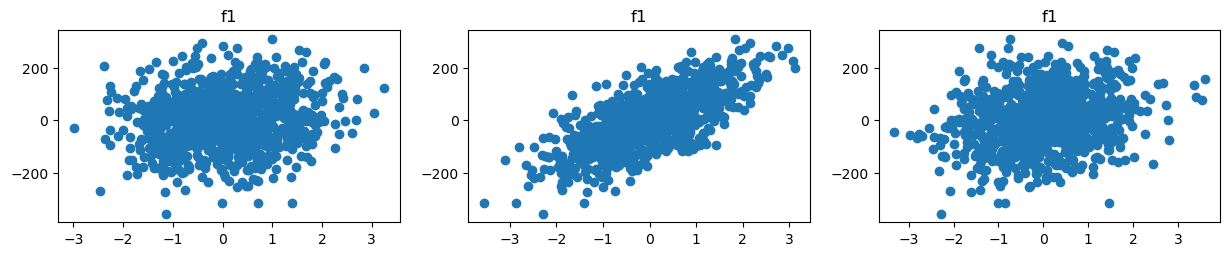

In [92]:
fig  ,(ax ,ax2 ,ax3 ) = plt.subplots(ncols=3,figsize=(15,2.5))
ax.scatter(x=df.f1,y=df.t)
ax.set_title("f1")
ax2.scatter(x=df.f2,y=df.t)
ax2.set_title("f1")

ax3.scatter(x=df.f3,y=df.t)
ax3.set_title("f1")

plt.show()

# 2.For Multicolinearity

<Axes: >

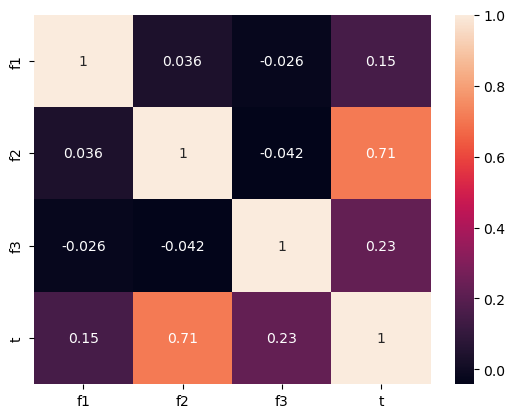

In [93]:
sns.heatmap(df.corr(),annot=True)

In [94]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [95]:
var = list()

In [96]:
for i in range(x.shape[1]):
    var.append(variance_inflation_factor(x,i))

In [97]:
var = pd.DataFrame({"vif" : var},index=df.columns[0:3]).T

In [98]:
var

,f1,f2,f3
vif,1.002001,1.003108,1.002333


# 3.For normal Residual

In [99]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

In [100]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.15,random_state=42)

In [101]:
x_train.shape

(850, 3)

In [102]:
lr = LinearRegression()

In [103]:
lr.fit(x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [104]:
pred = lr.predict(x_test)

In [105]:
residual = y_test - pred

<Axes: ylabel='Density'>

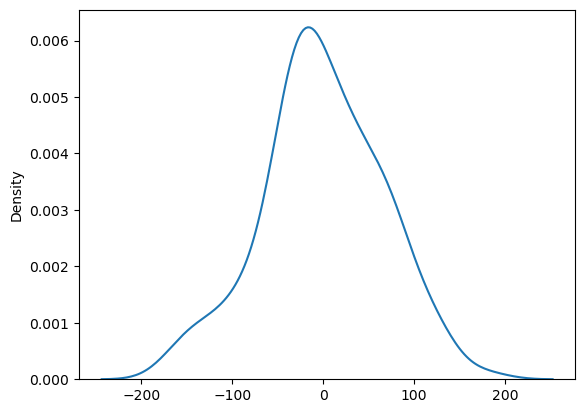

In [106]:
sns.kdeplot(residual)

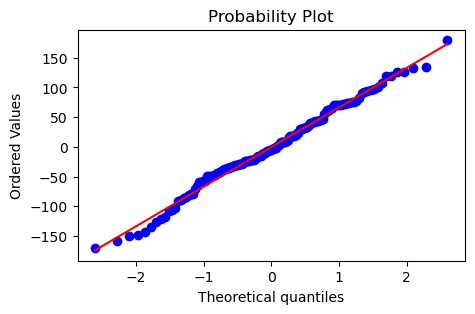

In [108]:
import  scipy as sp
fig , (ax) = plt.subplots(figsize=(5,3))
sp.stats.probplot(residual,plot=ax)
plt.show()

# 4.Homoscedasticity

<Axes: >

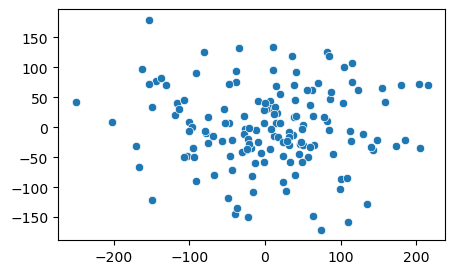

In [115]:
pl = plt.figure(figsize=(5,3))
sns.scatterplot(x=pred,y=residual)

# 5. NO auto corellation of error

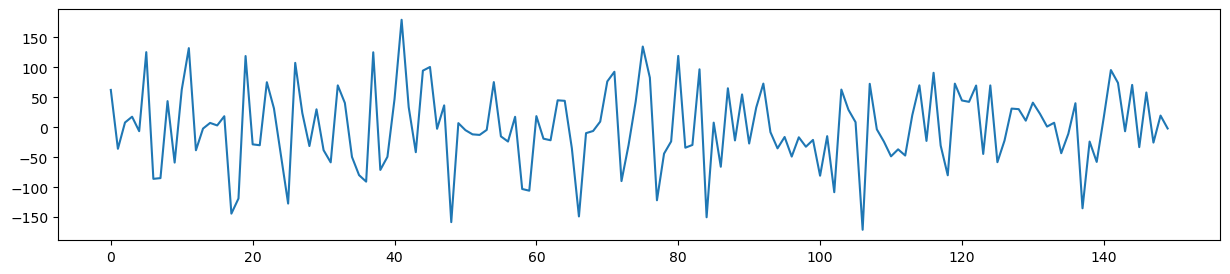

In [117]:
pl = plt.figure(figsize=(15,3))
plt.plot(residual)